# Benchmark Comparison: Combining Algorithms

This notebook analyses the results of two retrosynthetic planning benchmarks
that were run by `launch_bayesian_benchmark.sh` and `launch_standard_benchmark.sh`
(both in `scripts/benchmark/`).  Both benchmarks use the same two-phase solver:

- **Phase 1: UCT**: MCTS with Upper Confidence Bound for Trees, cold start.
- **Phase 2: BestFirst warm restart**: greedy best-first search seeded from
  Phase 1's expanded tree, giving molecules that UCT could not solve a second
  chance with a complementary exploration strategy.

The two configurations being compared are:

- **Bayesian Optimised**: hyperparameters (`c_ucb`, `top_rules`, `filtering_threshold`)
  tuned per SA-score bin via Bayesian optimisation.  Results in `results_{a,b,c,d}/`.
- **Standard (Default)**: SynPlanner default hyperparameters, ranking-only policy
  (no filtering network).  Results in `results_standard_{a,b,c,d}/`.

**Time-split variants** define how the 600s total budget is divided between
Phase 1 (UCT) and Phase 2 (BestFirst):
- Variant A: 300s / 300s
- Variant B: 200s / 400s
- Variant C: 100s / 500s
- Variant D: 400s / 200s

**SA-score bins** group target molecules by synthetic accessibility score (lower = easier):
`1.5-2.5`, `2.5-3.5`, `3.5-4.5`, `4.5-5.5`, `5.5-6.5`, `6.5-7.5`, `7.5-8.5`.

**Prerequisites**: run the benchmark scripts before executing this notebook.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 120

# TUTORIAL_DIR points to scripts/benchmark/ where result directories live.
TUTORIAL_DIR = Path('..') / 'scripts' / 'benchmark'

# Variants A–D differ only in how the 600s budget is split between UCT and BestFirst.
VARIANTS = ["a", "b", "c", "d"]
VARIANT_LABELS = {"a": "300/300", "b": "200/400", "c": "100/500", "d": "400/200"}

# METHODS defines the two benchmark configurations and how to find their result directories.
# Add more entries here to extend the comparison to additional configurations.
METHODS = {
    "bayesian": {
        "label": "Bayesian Optimised",
        "dir_pattern": "results_{var}",   # e.g. results_a/
        "color": "#e74c3c",
    },
    "standard": {
        "label": "Default",
        "dir_pattern": "results_standard_{var}",  # e.g. results_standard_a/
        "color": "#3498db",
    },
}

In [43]:
# ── Load all data ──────────────────────────────────────────────────────
# Set BIN_LABELS to a list of bins to analyse, or None for all.
# Example: BIN_LABELS = ["1.5_2.5", "2.5_3.5"]  to restrict to two bins.

BIN_LABELS = None  # e.g. ["1.5_2.5"] for a single bin, or None for all

# Discover available bins from the Bayesian Optimised variant-A directory.
# If results are not yet available, the cell prints a warning and sets all_bins=[]
# so downstream analysis cells can still be inspected without crashing.
ref_root = TUTORIAL_DIR / f"results_{VARIANTS[0]}"
if not ref_root.exists():
    print(f"Reference results directory not found: {ref_root}")
    print("Run launch_bayesian_benchmark.sh first.")
    all_bins = []
else:
    all_bins = sorted(
        (d.name.replace("sascore_", "") for d in ref_root.iterdir()
         if d.is_dir() and d.name.startswith("sascore_")),
        key=lambda x: float(x.split('_')[0]),
    )
bins_to_load = BIN_LABELS if BIN_LABELS else all_bins
print(f"Available bins: {all_bins}")
print(f"Loading bins:   {bins_to_load}")

# ── Load each method × variant ──────────────────────────────────────
# Each method/variant combination produces one results_log.csv per bin.
# We concatenate across bins and tag each row with its bin label.
method_frames = {}  # key: (method_key, variant) -> DataFrame

for method_key, method_info in METHODS.items():
    for var in VARIANTS:
        dir_name = method_info["dir_pattern"].format(var=var)
        var_root = TUTORIAL_DIR / dir_name
        parts = []
        for b in bins_to_load:
            csv_path = var_root / f"sascore_{b}" / "results_log.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df["bin"] = b
                parts.append(df)
        if parts:
            vdf = pd.concat(parts, ignore_index=True)
            method_frames[(method_key, var)] = vdf
            print(f"{method_key}/{VARIANT_LABELS[var]}: {len(vdf)} rows")
        else:
            print(f"{method_key}/{VARIANT_LABELS[var]}: no data found")

if not method_frames:
    print("\nNo data loaded. Run the benchmark scripts first.")
    merged = pd.DataFrame()
else:
    # ── Build merged DataFrame keyed by (bin, idx) ─────────────────────
    # Each method/variant's columns are prefixed with "<method>_<variant>_"
    # so all results live in a single wide DataFrame indexed by molecule.
    # This makes per-molecule comparisons (e.g. overlap analysis) straightforward.
    ref_key = next(iter(method_frames))  # first available method/variant as reference
    ref_df = method_frames[ref_key][["bin", "idx", "smiles", "canonical"]].copy()

    for (method_key, var), vdf in method_frames.items():
        prefix = f"{method_key}_{var}"
        rename_map = {
            "status":    f"{prefix}_status",
            "phase":     f"{prefix}_phase",
            "t_uct":     f"{prefix}_t_uct",
            "t_total":   f"{prefix}_t_total",
            "iters_uct": f"{prefix}_iters",
            "ram_mb":    f"{prefix}_ram",
        }
        vdf_renamed = vdf.rename(columns=rename_map)
        cols_to_merge = ["bin", "idx"] + [c for c in vdf_renamed.columns if c.startswith(prefix)]
        ref_df = ref_df.merge(vdf_renamed[cols_to_merge], on=["bin", "idx"], how="outer")

    merged = ref_df.copy()

    # Convenience boolean columns: True if this method+variant solved the molecule
    for (method_key, var) in method_frames:
        prefix = f"{method_key}_{var}"
        merged[f"{prefix}_solved"] = merged[f"{prefix}_status"] == "solved"

    # Convenience boolean columns: True if *any* variant of this method solved the molecule
    for method_key in METHODS:
        var_cols = [f"{method_key}_{var}_solved" for var in VARIANTS
                   if f"{method_key}_{var}_solved" in merged.columns]
        if var_cols:
            merged[f"{method_key}_any_solved"] = merged[var_cols].any(axis=1)

    print(f"\nMerged DataFrame: {merged.shape}")
    merged.head()

Available bins: ['1.5_2.5', '2.5_3.5', '3.5_4.5', '4.5_5.5', '5.5_6.5', '6.5_7.5', '7.5_8.5']
Loading bins:   ['1.5_2.5', '2.5_3.5', '3.5_4.5', '4.5_5.5', '5.5_6.5', '6.5_7.5', '7.5_8.5']
bayesian/300/300: 700 rows
bayesian/200/400: 700 rows
bayesian/100/500: 700 rows
bayesian/400/200: 700 rows
standard/300/300: 700 rows
standard/200/400: 700 rows
standard/100/500: 700 rows
standard/400/200: 700 rows

Merged DataFrame: (700, 46)


## Analysis 1: Solve Rates (best variant per method)

For each SA-score bin, we report:
- **Best**: solve rate of the best time-split variant (A–D) for each method.
- **Mean / Min**: across all four variants.

The bar chart compares the best-case performance of each method per bin.
The per-variant breakdown below it shows how sensitive each method is to
the UCT/BestFirst time split.

,bin,n_molecules,bayesian_best,bayesian_mean,bayesian_min,standard_best,standard_mean,standard_min
0,1.5_2.5,100,89.0,87.75,87.0,82.0,81.25,81.0
1,2.5_3.5,100,67.0,61.50,57.0,44.0,43.75,43.0
2,3.5_4.5,100,40.0,37.00,34.0,23.0,21.50,20.0
3,4.5_5.5,100,10.0,5.25,3.0,3.0,2.25,2.0
4,5.5_6.5,100,9.0,9.00,9.0,8.0,8.00,8.0
5,6.5_7.5,100,0.0,0.00,0.0,0.0,0.00,0.0
6,7.5_8.5,100,2.0,2.00,2.0,1.0,1.00,1.0


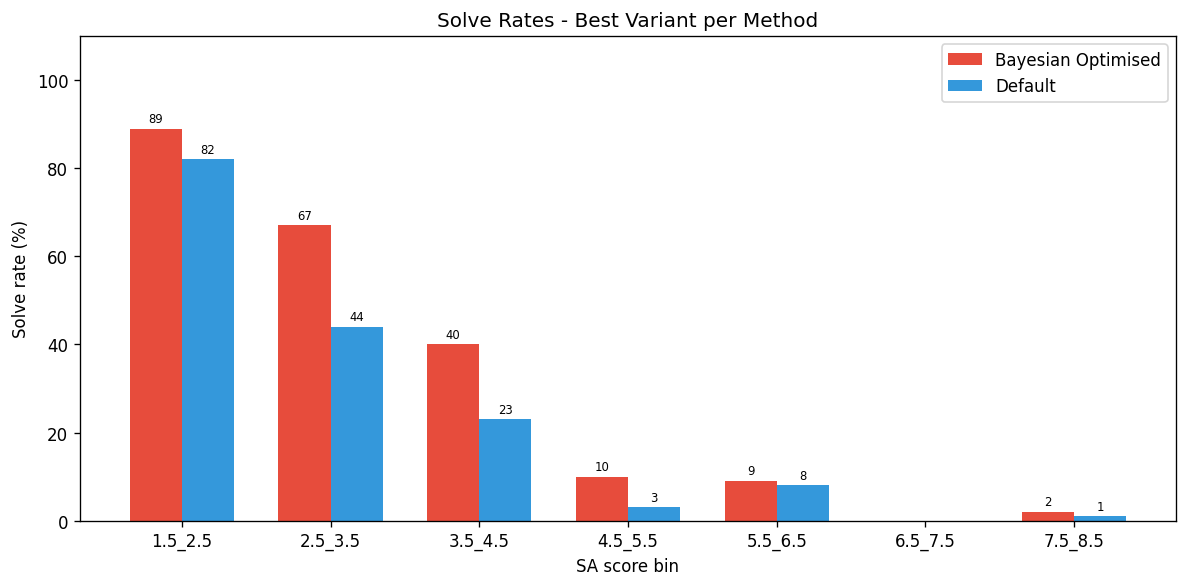

In [44]:
# For each method, compute per-bin solve rate as the best across variants A-D
rate_rows = []
for b in bins_to_load:
    bdf = merged[merged["bin"] == b]
    n = len(bdf)
    row = {"bin": b, "n_molecules": n}
    for method_key, method_info in METHODS.items():
        var_rates = []
        for var in VARIANTS:
            col = f"{method_key}_{var}_solved"
            if col in bdf.columns:
                var_rates.append(bdf[col].sum() / n * 100)
        row[f"{method_key}_best"] = max(var_rates) if var_rates else 0
        row[f"{method_key}_mean"] = np.mean(var_rates) if var_rates else 0
        row[f"{method_key}_min"] = min(var_rates) if var_rates else 0
    rate_rows.append(row)

rate_df = pd.DataFrame(rate_rows)
display(rate_df)

# Bar chart: best variant per method
method_keys = list(METHODS.keys())
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(bins_to_load))
width = 0.35
for i, mk in enumerate(method_keys):
    offsets = x_pos + width * i
    bars = ax.bar(offsets, rate_df[f"{mk}_best"], width,
                  label=METHODS[mk]["label"], color=METHODS[mk]["color"])
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                    f"{h:.0f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(rate_df["bin"])
ax.set_ylabel("Solve rate (%)")
ax.set_xlabel("SA score bin")
ax.set_title("Solve Rates - Best Variant per Method")
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()


In [45]:
# Add Baseline overlay (manual and optional)

baseline_bins = ["1.5_2.5", "2.5_3.5", "3.5_4.5", "4.5_5.5", "5.5_6.5", "6.5_7.5", "7.5_8.5"]
baseline_counts = [82, 51, 21, 4, 7, 0, 1]

baseline_rates = dict(zip(baseline_bins, baseline_counts))

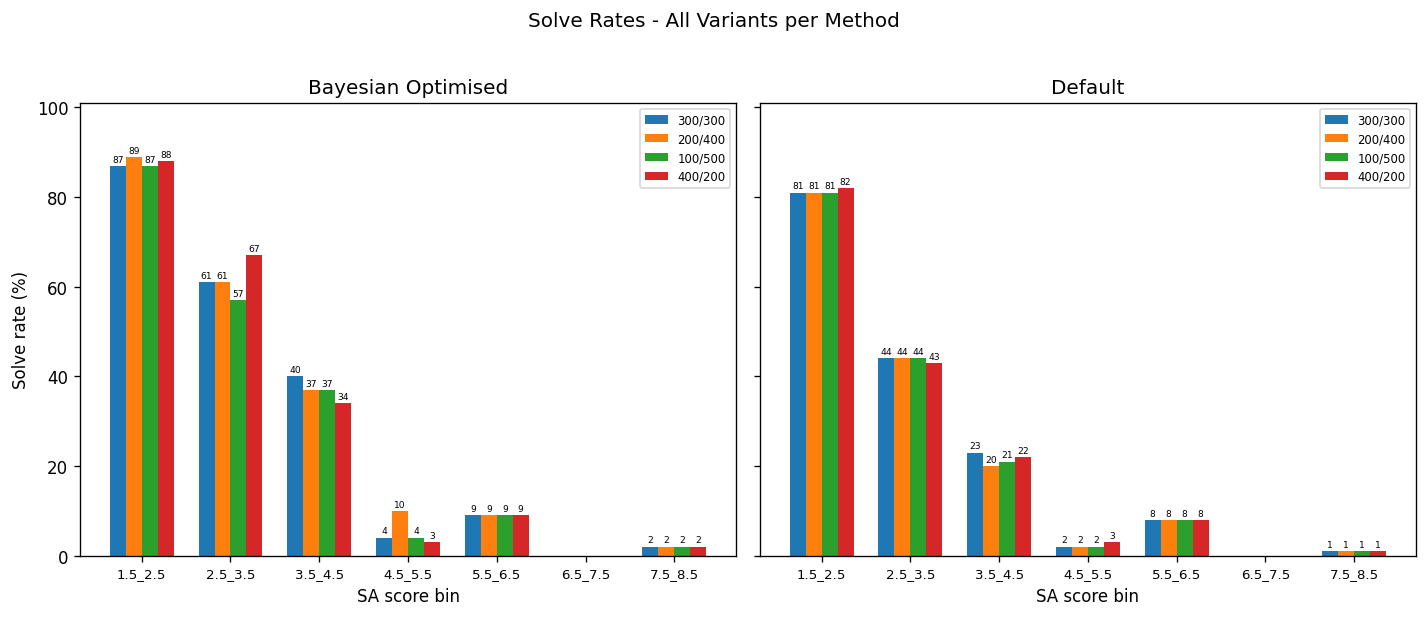

In [46]:
# All variants side-by-side per method
fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 5),
                         sharey=True, squeeze=False)
for ax_i, (mk, minfo) in enumerate(METHODS.items()):
    ax = axes[0, ax_i]
    x_pos = np.arange(len(bins_to_load))
    width = 0.18
    for vi, var in enumerate(VARIANTS):
        rates = []
        for b in bins_to_load:
            bdf = merged[merged["bin"] == b]
            col = f"{mk}_{var}_solved"
            rates.append(bdf[col].sum() / len(bdf) * 100 if col in bdf.columns else 0)
        bars = ax.bar(x_pos + width * vi, rates, width, label=VARIANT_LABELS[var])
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                        f"{h:.0f}", ha="center", va="bottom", fontsize=5.5)
    ax.set_xticks(x_pos + width * 1.5)
    ax.set_xticklabels(bins_to_load, fontsize=8)
    ax.set_title(minfo["label"])
    ax.set_xlabel("SA score bin")
    if ax_i == 0:
        ax.set_ylabel("Solve rate (%)")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 101)
plt.suptitle("Solve Rates - All Variants per Method", y=1.02)
plt.tight_layout()
plt.show()


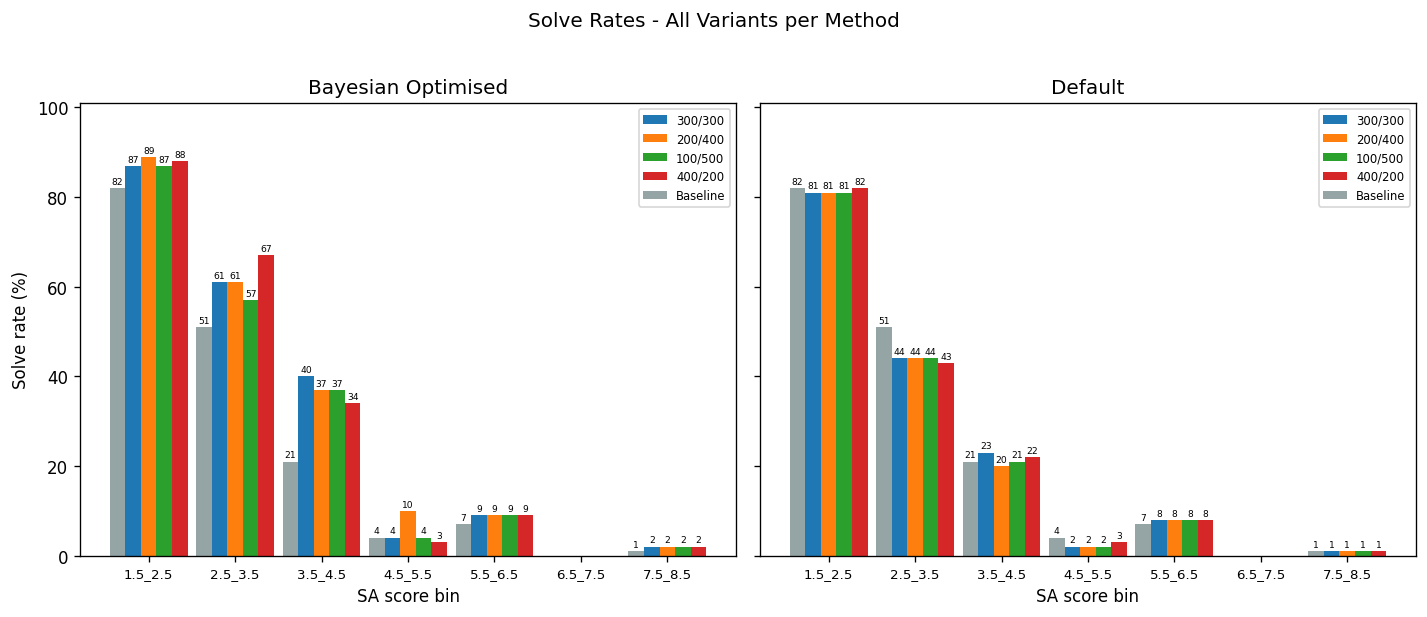

In [47]:
# With manual baseline added and reformating
# All variants side-by-side per method
fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 5),
                         sharey=True, squeeze=False)
for ax_i, (mk, minfo) in enumerate(METHODS.items()):
    ax = axes[0, ax_i]
    x_pos = np.arange(len(bins_to_load))
    width = 0.18
    for vi, var in enumerate(VARIANTS):
        rates = []
        for b in bins_to_load:
            bdf = merged[merged["bin"] == b]
            col = f"{mk}_{var}_solved"
            rates.append(bdf[col].sum() / len(bdf) * 100 if col in bdf.columns else 0)
        bars = ax.bar(x_pos + width * (vi + 1), rates, width, label=VARIANT_LABELS[var])
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                        f"{h:.0f}", ha="center", va="bottom", fontsize=5.5)
    if 'baseline_rates' in locals():
        bl = [baseline_rates.get(b, 0) for b in bins_to_load]
        bars = ax.bar(x_pos + width * 0, bl, width,
                      label="Baseline", color="#95a5a6")
        for bar, h in zip(bars, bl):
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                        f"{h:.0f}", ha="center", va="bottom", fontsize=5.5)
    ax.set_xticks(x_pos + width * len(VARIANTS) / 2)
    ax.set_xticklabels(bins_to_load, fontsize=8)
    ax.set_title(minfo["label"])
    ax.set_xlabel("SA score bin")
    if ax_i == 0:
        ax.set_ylabel("Solve rate (%)")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 101)
plt.suptitle("Solve Rates - All Variants per Method", y=1.02)
plt.tight_layout()
plt.savefig('combining_algorithms_results.png', dpi=300)
plt.show()

## Analysis 2: Head-to-Head Overlap

For each SA-score bin and each pair of methods, we count (using the *any variant*
aggregation) how many molecules fall into four categories:

- **Both solved**: solved by both methods.
- **Method A only**: solved by the first method but not the second: unique contribution.
- **Method B only**: vice versa.
- **Neither**: unsolved by both methods: hard molecules for the current setup.

Large "A only" or "B only" bars would indicate that the two methods explore different
parts of the search space and could benefit from being combined (not the case here).

,bin,pair,pair_key,both_solved,bayesian_only,standard_only,neither
0,1.5_2.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,82,7,0,11
1,2.5_3.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,44,25,1,30
2,3.5_4.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,22,19,2,57
3,4.5_5.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,3,7,0,90
4,5.5_6.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,8,1,0,91
5,6.5_7.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,0,0,0,100
6,7.5_8.5,Bayesian Optimised\nvs\nDefault,bayesian_vs_standard,1,1,0,98


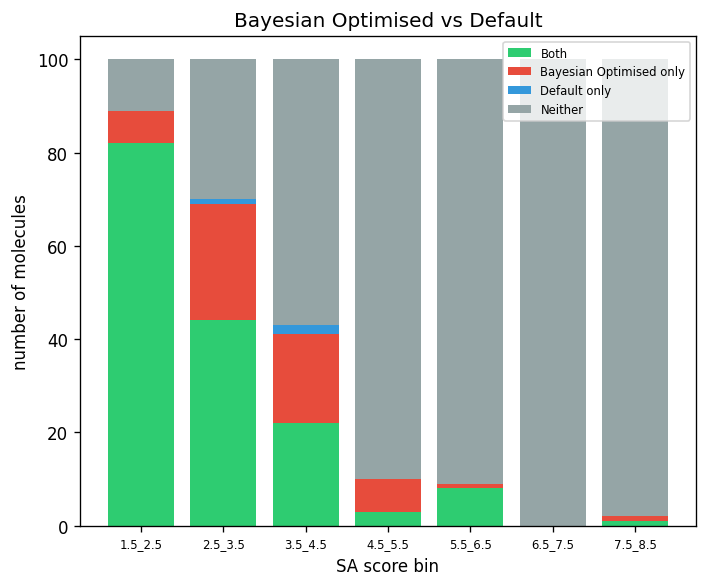

In [48]:
# Pairwise overlap: for each pair of methods, count both_solved, A_only, B_only, neither
# Using "any variant solved" per method
method_keys = list(METHODS.keys())
pairs = [(method_keys[i], method_keys[j])
         for i in range(len(method_keys))
         for j in range(i + 1, len(method_keys))]

overlap_rows = []
for a, b_key in pairs:
    for b in bins_to_load:
        bdf = merged[merged["bin"] == b]
        a_solved = bdf[f"{a}_any_solved"]
        b_solved = bdf[f"{b_key}_any_solved"]
        both = (a_solved & b_solved).sum()
        a_only = (a_solved & ~b_solved).sum()
        b_only = (~a_solved & b_solved).sum()
        neither = (~a_solved & ~b_solved).sum()
        overlap_rows.append({
            "bin": b, "pair": f"{METHODS[a]['label']}\nvs\n{METHODS[b_key]['label']}",
            "pair_key": f"{a}_vs_{b_key}",
            "both_solved": int(both),
            f"{a}_only": int(a_only),
            f"{b_key}_only": int(b_only),
            "neither": int(neither),
        })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)

# Stacked bar chart per pair
fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5),
                         sharey=True, squeeze=False)
for pi, (a, b_key) in enumerate(pairs):
    ax = axes[0, pi]
    pdf = overlap_df[overlap_df["pair_key"] == f"{a}_vs_{b_key}"]
    cats = ["both_solved", f"{a}_only", f"{b_key}_only", "neither"]
    cat_labels = ["Both", f"{METHODS[a]['label']} only",
                  f"{METHODS[b_key]['label']} only", "Neither"]
    colors = ["#2ecc71", METHODS[a]["color"], METHODS[b_key]["color"], "#95a5a6"]
    bottom = np.zeros(len(pdf))
    for cat, label, color in zip(cats, cat_labels, colors):
        if cat in pdf.columns:
            vals = pdf[cat].values.astype(float)
        else:
            vals = np.zeros(len(pdf))
        ax.bar(pdf["bin"].values, vals, bottom=bottom, label=label, color=color)
        bottom += vals
    ax.set_title(f"{METHODS[a]['label']} vs {METHODS[b_key]['label']}")
    ax.set_xlabel("SA score bin")
    if pi == 0:
        ax.set_ylabel("number of molecules")
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

## Analysis 3: Phase Attribution (UCT vs BestFirst)

The `phase` column in `results_log.csv` records which search phase found the route:
- **Phase 1 (UCT)**: molecule was solved during the cold-start UCT search.
- **Phase 2 (BestFirst)**: UCT did not find a route; BestFirst warm restart succeeded.

This analysis shows how many solved molecules each phase contributes, averaged
across all four time-split variants.  A large Phase 2 contribution means the
warm-restart strategy is adding value beyond UCT alone.

,method,bin,UCT,BestFirst
0,Bayesian Optimised,1.5_2.5,86.50,1.25
1,Bayesian Optimised,2.5_3.5,43.50,18.00
2,Bayesian Optimised,3.5_4.5,22.00,15.00
3,Bayesian Optimised,4.5_5.5,3.00,2.25
4,Bayesian Optimised,5.5_6.5,8.00,1.00
5,Bayesian Optimised,6.5_7.5,0.00,0.00
6,Bayesian Optimised,7.5_8.5,2.00,0.00
7,Default,1.5_2.5,69.00,12.25
8,Default,2.5_3.5,30.25,13.50
9,Default,3.5_4.5,12.75,8.75


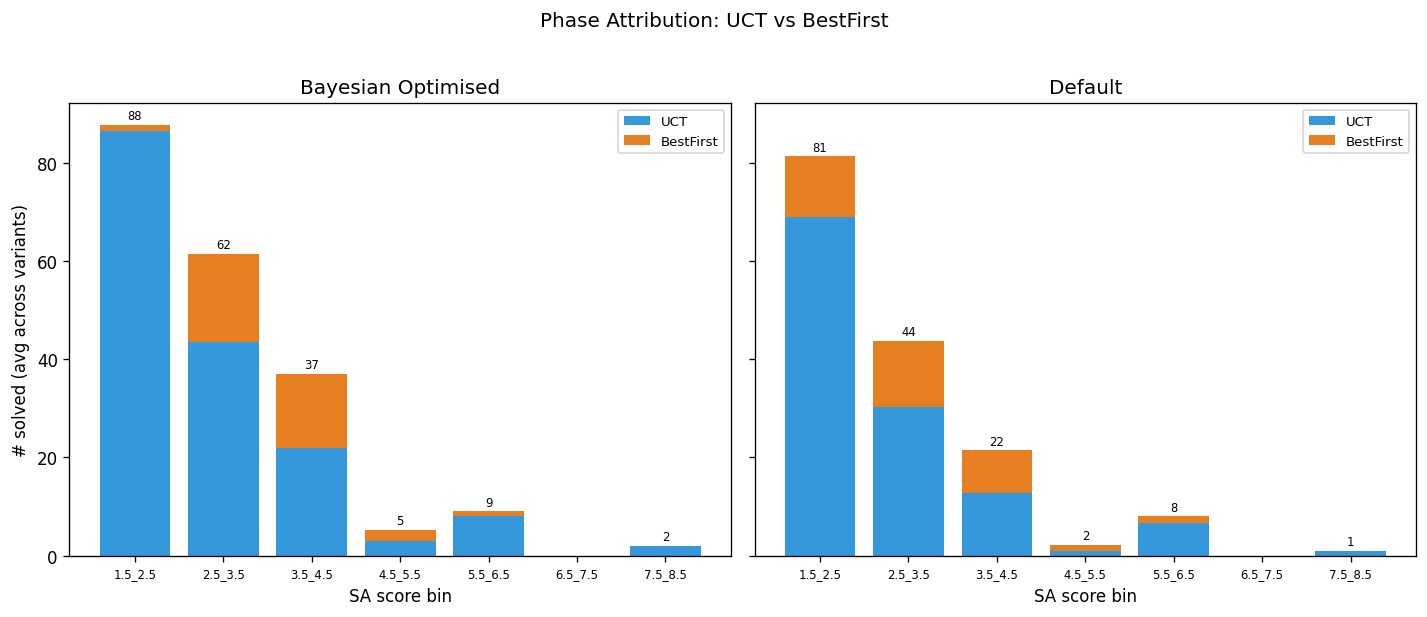

In [50]:
# For each method and variant, breakdown of solved molecules by phase
phase_rows = []
for mk, minfo in METHODS.items():
    for var in VARIANTS:
        prefix = f"{mk}_{var}"
        solved_mask = merged[f"{prefix}_solved"]
        for b in bins_to_load:
            bdf = merged[(merged["bin"] == b) & solved_mask]
            uct = (bdf[f"{prefix}_phase"] == 1).sum()
            best_first = (bdf[f"{prefix}_phase"] == 2).sum()
            phase_rows.append({
                "method": minfo["label"], "variant": var, "bin": b,
                "UCT": int(uct), "BestFirst": int(best_first),
                "total_solved": int(uct + best_first),
            })

phase_df = pd.DataFrame(phase_rows)

# Aggregate across variants: mean P1 and P2 per method × bin
phase_agg = phase_df.groupby(["method", "bin"]).agg(
    UCT=pd.NamedAgg(column="UCT", aggfunc="mean"),
    BestFirst=pd.NamedAgg(column="BestFirst", aggfunc="mean"),
).reset_index()
display(phase_agg)

# Stacked bar chart per method
fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 5),
                         sharey=True, squeeze=False)
for mi, (mk, minfo) in enumerate(METHODS.items()):
    ax = axes[0, mi]
    mdf = phase_agg[phase_agg["method"] == minfo["label"]]
    ax.bar(mdf["bin"], mdf["UCT"], label="UCT", color="#3498db")
    ax.bar(mdf["bin"], mdf["BestFirst"], bottom=mdf["UCT"],
           label="BestFirst", color="#e67e22")
    for _, row in mdf.iterrows():
        total = row["UCT"] + row["BestFirst"]
        if total > 0:
            ax.text(row["bin"], total + 0.5, f"{total:.0f}",
                    ha="center", va="bottom", fontsize=7)
    ax.set_title(minfo["label"])
    ax.set_xlabel("SA score bin")
    if mi == 0:
        ax.set_ylabel("# solved (avg across variants)")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', labelsize=7)
plt.suptitle("Phase Attribution: UCT vs BestFirst", y=1.02)
plt.tight_layout()
plt.show()

## Analysis 4: Time-to-Solve Distribution

Using variant D (400 s UCT / 200 s BestFirst) as a representative example,
we plot the distribution of total solve times for each method:

- **Histogram**: raw count of solved molecules at each solve time.
- **CDF**: cumulative fraction of solved molecules as a function of elapsed time.
  A curve that rises steeply at low times indicates that many molecules are solved
  quickly; a long flat tail suggests a few molecules consume most of the budget.

Here, a very large fraction of molecules is solved in the first 200s of the search, following a solvability plateau. 
Default hyperparameters benefit instantly from the change in algorithm, as shown by the sudden peak at 400s.
The bayesian-optimised set see a more modest improvement from this switch, suggesting that bayesian optimisation already
helped solving molecules that would have benefited from the algorithm change.

Change `rep_var` to compare a different time-split variant.

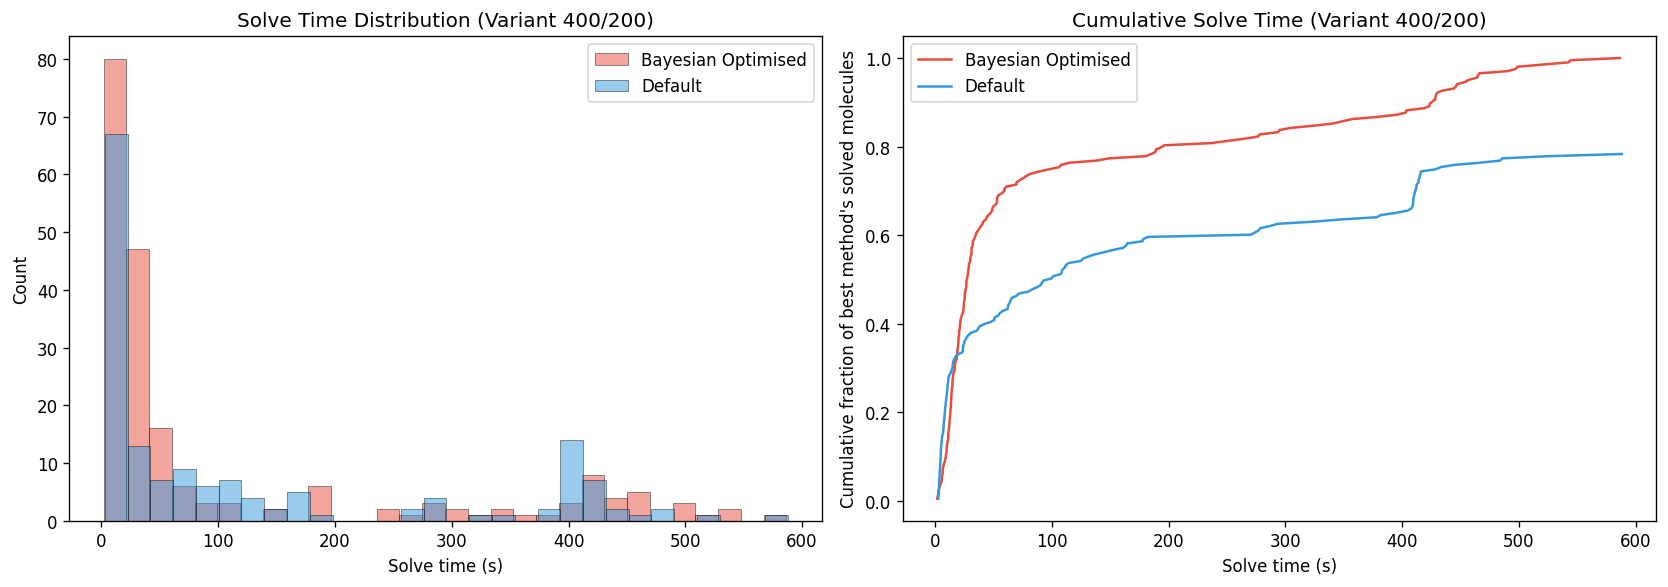

In [51]:
# CDF of solve times for each method (using variant "d" as representative, modify at will)
rep_var = "d"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram ─────────────────────────────────────────────────────
ax = axes[0]
for mk, minfo in METHODS.items():
    prefix = f"{mk}_{rep_var}"
    times = merged.loc[merged[f"{prefix}_solved"], f"{prefix}_t_total"].dropna()
    ax.hist(times, bins=30, alpha=0.5, label=minfo["label"],
            color=minfo["color"], edgecolor="black", linewidth=0.5)
ax.set_xlabel("Solve time (s)")
ax.set_ylabel("Count")
ax.set_title(f"Solve Time Distribution (Variant {VARIANT_LABELS[rep_var]})")
ax.legend()

# ── CDF ────────────────────────────────────────────────────────────
ax = axes[1]
# Normalise all CDFs by the best (bayesian) method's solved count so that
# only the bayesian curve reaches 1.0 and the gap in solvability is visible.
best_key = "bayesian"
best_n = merged[f"{best_key}_{rep_var}_solved"].sum()
for mk, minfo in METHODS.items():
    prefix = f"{mk}_{rep_var}"
    times = merged.loc[merged[f"{prefix}_solved"], f"{prefix}_t_total"].dropna()
    if len(times) > 0:
        sorted_t = sorted(times)
        cdf = [i / best_n for i in range(1, len(sorted_t) + 1)]
        ax.plot(sorted_t, cdf, label=minfo["label"], color=minfo["color"])
ax.set_xlabel("Solve time (s)")
ax.set_ylabel("Cumulative fraction of best method's solved molecules")
ax.set_title(f"Cumulative Solve Time (Variant {VARIANT_LABELS[rep_var]})")
ax.legend()

plt.tight_layout()
plt.show()
